# 06 - Comparaison des modèles de prédiction de rendement

**Objectif** : Comparer Logistic Regression, XGBoost et Random Forest pour la prédiction de rendement.

**Modèles testés** :
- Logistic Regression (baseline interprétable)
- XGBoost (gradient boosting)
- Random Forest (ensemble d'arbres)

**Métriques** :
- Accuracy (directional accuracy)
- AUC-ROC
- Precision / Recall / F1
- Overfitting gap (train vs test)

**Validation** : Walk-forward (pas de look-ahead)

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Modules ML DeepPilot
from ml.config import ETF_TICKERS, REGIME_NAMES, PREDICTION_HORIZON
from ml.features.feature_engineering import (
    prepare_regime_features,
    prepare_prediction_features,
    create_target,
)
from ml.features.time_split import walk_forward_split
from ml.models.regime_hmm import RegimeHMM
from ml.models.predict_logreg import ReturnPredictorLogReg
from ml.models.predict_xgboost import ReturnPredictorXGBoost
from ml.models.predict_rf import ReturnPredictorRF
from ml.evaluation.compare_prediction_models import (
    evaluate_prediction_model,
    compare_all_prediction_models,
    walk_forward_comparison,
    get_feature_importance_comparison,
)

# Database
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Imports OK")

Imports OK


## 1. Chargement des données

In [2]:
# Connexion DB
DATABASE_URL = os.getenv("SUPABASE_DB_URL")
engine = create_engine(DATABASE_URL)

# Charger prix ETF
query_prices = """
SELECT date, ticker, close
FROM price
WHERE ticker IN ('SPY', 'TLT', 'GLD', 'VNQ', 'EFA', 'EEM', 'HYG', 'SH')
ORDER BY date, ticker
"""
df_prices_long = pd.read_sql(query_prices, engine, parse_dates=['date'])
df_prices = df_prices_long.pivot(index='date', columns='ticker', values='close')

# Charger macro
query_macro = """
SELECT date, vix, credit_spread_hy, yield_curve_10y2y, t10y as treasury_10y
FROM macro_indicator
ORDER BY date
"""
df_macro = pd.read_sql(query_macro, engine, parse_dates=['date'])
df_macro = df_macro.set_index('date')

# Remplir les valeurs manquantes de credit_spread_hy
if df_macro['credit_spread_hy'].isna().any():
    df_macro['credit_spread_hy'] = df_macro['credit_spread_hy'].ffill().bfill()
    df_macro['credit_spread_hy'] = df_macro['credit_spread_hy'].fillna(4.5)
    print("[INFO] credit_spread_hy: valeurs manquantes remplies")

# Combiner
df_combined = pd.concat([df_prices, df_macro], axis=1).dropna()

print(f"Données : {df_combined.shape[0]} jours")
print(f"Période : {df_combined.index.min().date()} à {df_combined.index.max().date()}")

[INFO] credit_spread_hy: valeurs manquantes remplies
Données : 4109 jours
Période : 2010-01-04 à 2026-05-05


## 2. Préparer les régimes (HMM)

In [3]:
# Préparer features de régime et entraîner HMM
X_regime = prepare_regime_features(df_combined)

print("Entraînement HMM pour les régimes...")
model_hmm = RegimeHMM()
model_hmm.fit(X_regime)
regimes = model_hmm.predict_series(X_regime)

print(f"Régimes prédits : {len(regimes)} observations")
print(f"Distribution : {regimes.value_counts().sort_index().to_dict()}")

Entraînement HMM pour les régimes...
Régimes prédits : 4109 observations
Distribution : {0: 1016, 1: 1066, 2: 420, 3: 1607}


## 3. Préparer les features de prédiction pour SPY

In [4]:
# On commence avec SPY comme ticker principal
TICKER = 'SPY'

# Préparer features de prédiction
X_pred = prepare_prediction_features(df_combined, TICKER, regimes)

# Préparer target
y = create_target(df_combined, TICKER, horizon=PREDICTION_HORIZON)

# Aligner
common_idx = X_pred.index.intersection(y.index)
X_pred = X_pred.loc[common_idx]
y = y.loc[common_idx]

# Enlever NaN
valid_mask = ~(X_pred.isna().any(axis=1) | y.isna())
X_pred = X_pred[valid_mask]
y = y[valid_mask]

print(f"Features de prédiction : {X_pred.shape}")
print(f"Colonnes : {list(X_pred.columns)}")
print(f"\nTarget : {len(y)} observations")
print(f"Distribution : {y.value_counts().to_dict()}")
print(f"% positifs : {y.mean()*100:.1f}%")

Features de prédiction : (3910, 10)
Colonnes : ['return_1d', 'return_5d', 'return_20d', 'price_sma20_ratio', 'price_sma50_ratio', 'price_sma200_ratio', 'rsi_14', 'macd_signal_ratio', 'bb_position', 'regime']

Target : 3910 observations
Distribution : {1: 2680, 0: 1230}
% positifs : 68.5%


In [5]:
# Aperçu des features
X_pred.describe().round(3)

,return_1d,return_5d,return_20d,price_sma20_ratio,price_sma50_ratio,price_sma200_ratio,rsi_14,macd_signal_ratio,bb_position,regime
count,3910.000,3910.000,3910.000,3910.000,3910.000,3910.000,3910.000,3910.000,3910.000,3910.000
mean,0.001,0.003,0.012,1.005,1.013,1.055,57.356,1.210,0.614,1.602
std,0.011,0.022,0.041,0.023,0.035,0.059,16.176,8.764,0.298,1.243
min,-0.109,-0.180,-0.310,0.799,0.726,0.743,3.990,-141.874,0.000,0.000
25%,-0.004,-0.007,-0.008,0.995,0.998,1.029,45.596,0.780,0.400,0.000
50%,0.001,0.005,0.017,1.009,1.019,1.066,57.978,1.012,0.703,1.000
75%,0.006,0.015,0.035,1.019,1.036,1.093,68.663,1.257,0.852,3.000
max,0.105,0.174,0.231,1.115,1.133,1.178,97.677,332.589,1.000,3.000


## 4. Split train/test simple

In [6]:
# Split temporel 70/30
split_idx = int(len(X_pred) * 0.7)

X_train = X_pred.iloc[:split_idx]
X_test = X_pred.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train : {len(X_train)} observations ({X_train.index.min().date()} à {X_train.index.max().date()})")
print(f"Test  : {len(X_test)} observations ({X_test.index.min().date()} à {X_test.index.max().date()})")
print(f"\n% positifs train : {y_train.mean()*100:.1f}%")
print(f"% positifs test  : {y_test.mean()*100:.1f}%")

Train : 2737 observations (2010-10-18 à 2021-08-31)
Test  : 1173 observations (2021-09-01 à 2026-05-05)

% positifs train : 70.9%
% positifs test  : 63.0%


## 5. Entraînement et comparaison des modèles

In [7]:
# Comparaison automatique
comparison_df = compare_all_prediction_models(X_train, y_train, X_test, y_test)

print("\n" + "="*70)
print("COMPARAISON DES MODÈLES DE PRÉDICTION")
print("="*70)
comparison_df

Entraînement Logistic Regression...
Entraînement XGBoost...
Entraînement Random Forest...

COMPARAISON DES MODÈLES DE PRÉDICTION


,accuracy,auc,precision,recall,f1,log_loss,overfit_gap
model,,,,,,,
Logistic Regression,0.6300,0.4644,0.6300,1.0000,0.7730,0.6939,0.0792
XGBoost,0.5806,0.4942,0.6275,0.8227,0.7119,0.7958,0.2905
Random Forest,0.6215,0.4926,0.6328,0.9513,0.7600,0.7143,0.1732


In [8]:
# Entraîner chaque modèle pour analyse détaillée
models = {
    'Logistic Regression': ReturnPredictorLogReg(),
    'XGBoost': ReturnPredictorXGBoost(),
    'Random Forest': ReturnPredictorRF(),
}

trained_models = {}
for name, model in models.items():
    print(f"Entraînement {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"  OK")

Entraînement Logistic Regression...
  OK
Entraînement XGBoost...
  OK
Entraînement Random Forest...
  OK


## 6. Courbes ROC

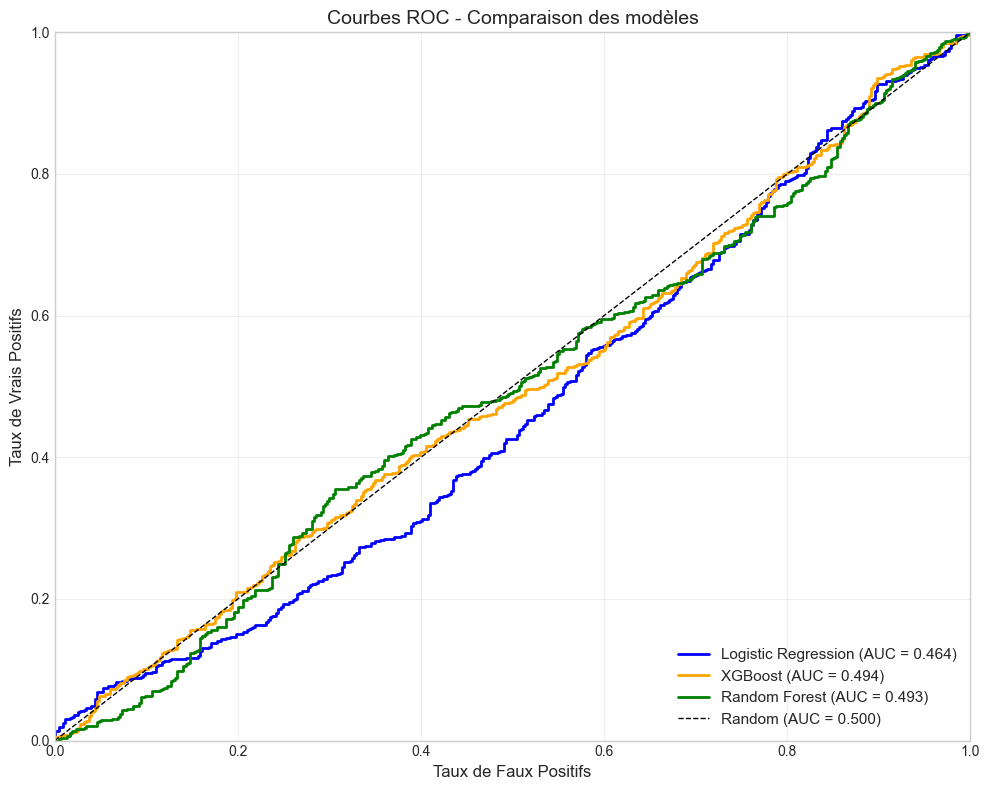

In [9]:
# Tracer les courbes ROC
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['blue', 'orange', 'green']

for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs', fontsize=12)
ax.set_title('Courbes ROC - Comparaison des modèles', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Matrices de confusion

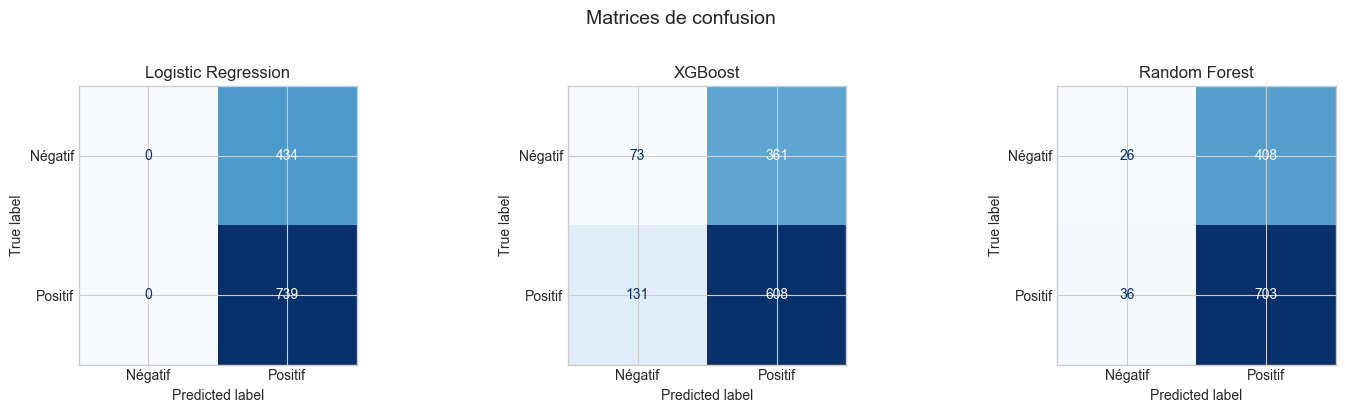

In [10]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(cm, display_labels=['Négatif', 'Positif'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=12)

plt.suptitle('Matrices de confusion', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Walk-Forward Validation

In [11]:
# Walk-forward validation (plus rigoureux)
print("Walk-Forward Validation (3 ans train, 1 an test)...")
print("Cela peut prendre quelques minutes...\n")

wf_results = walk_forward_comparison(X_pred, y, train_years=3, test_years=1)

print("\n" + "="*70)
print("RÉSULTATS WALK-FORWARD")
print("="*70)
wf_results

Walk-Forward Validation (3 ans train, 1 an test)...
Cela peut prendre quelques minutes...

Fold 1...
Fold 2...
Fold 3...
Fold 4...
Fold 5...
Fold 6...
Fold 7...
Fold 8...
Fold 9...
Fold 10...
Fold 11...
Fold 12...

RÉSULTATS WALK-FORWARD


,accuracy_mean,accuracy_std,auc_mean,auc_std,f1_mean,overfit_gap_mean,n_folds
model,,,,,,,
Logistic Regression,0.5850,0.1093,0.5059,0.1289,0.7146,0.1232,12
XGBoost,0.5608,0.0888,0.5057,0.1007,0.6800,0.4284,12
Random Forest,0.5565,0.1094,0.4840,0.0992,0.6812,0.3558,12


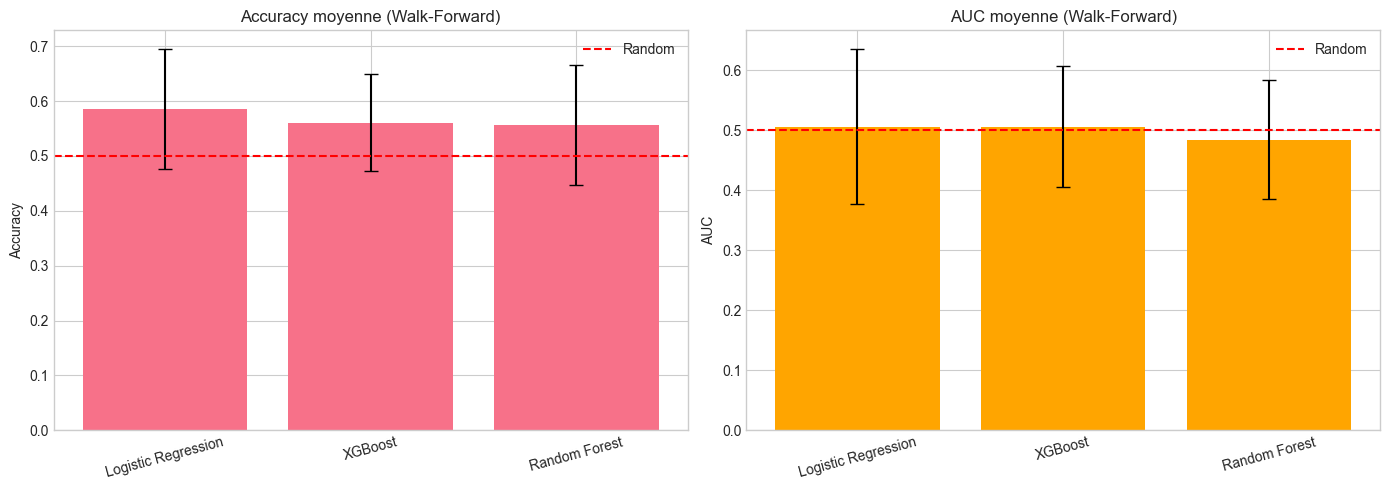

In [12]:
# Visualiser les résultats walk-forward
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1 = axes[0]
x = range(len(wf_results))
ax1.bar(x, wf_results['accuracy_mean'], yerr=wf_results['accuracy_std'], capsize=5)
ax1.set_xticks(x)
ax1.set_xticklabels(wf_results.index, rotation=15)
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy moyenne (Walk-Forward)', fontsize=12)
ax1.axhline(y=0.5, color='red', linestyle='--', label='Random')
ax1.legend()

# AUC
ax2 = axes[1]
ax2.bar(x, wf_results['auc_mean'], yerr=wf_results['auc_std'], capsize=5, color='orange')
ax2.set_xticks(x)
ax2.set_xticklabels(wf_results.index, rotation=15)
ax2.set_ylabel('AUC')
ax2.set_title('AUC moyenne (Walk-Forward)', fontsize=12)
ax2.axhline(y=0.5, color='red', linestyle='--', label='Random')
ax2.legend()

plt.tight_layout()
plt.show()

## 9. Importance des features

In [13]:
# Comparaison de l'importance des features
importance_df = get_feature_importance_comparison(X_train, y_train, top_n=10)

print("Top 10 features par importance moyenne :")
importance_df

Top 10 features par importance moyenne :


,feature,logreg,xgboost,random_forest,mean_importance
5,price_sma200_ratio,0.284497,0.137464,0.202079,0.208013
6,rsi_14,0.257734,0.098578,0.128999,0.161770
4,price_sma50_ratio,0.095298,0.100881,0.108283,0.101487
3,price_sma20_ratio,0.081526,0.096596,0.104117,0.094080
9,regime,0.079680,0.138603,0.036249,0.084844
1,return_5d,0.067793,0.086885,0.080753,0.078477
7,macd_signal_ratio,0.042371,0.091432,0.099644,0.077816
2,return_20d,0.030357,0.092111,0.090611,0.071026
8,bb_position,0.027675,0.087008,0.086458,0.067047
0,return_1d,0.033069,0.070443,0.062806,0.055440


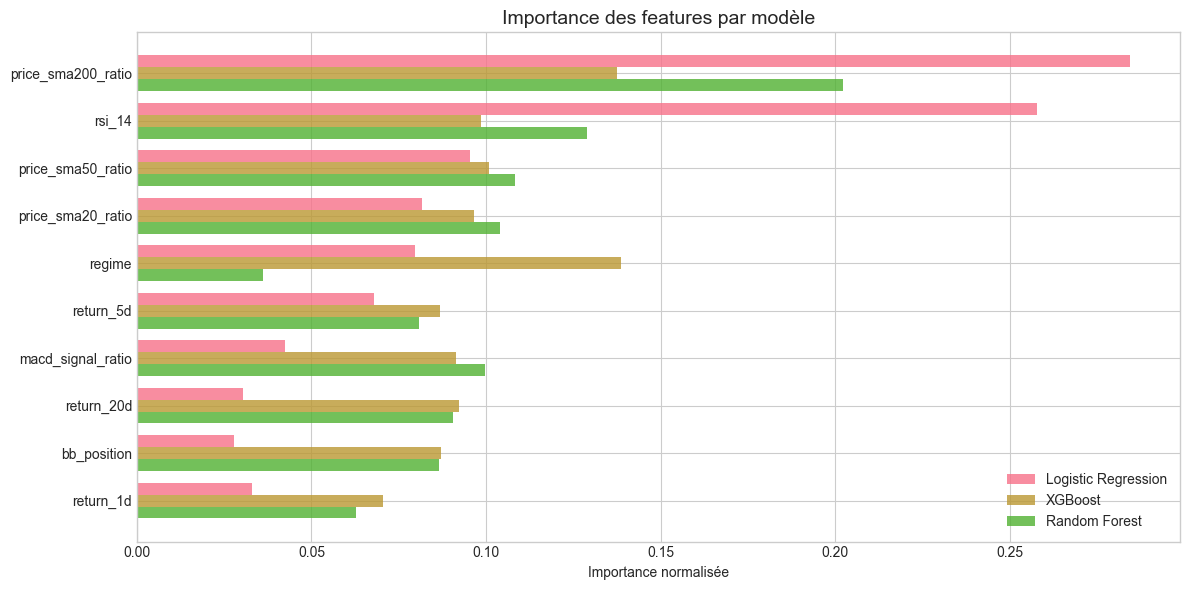

In [14]:
# Visualiser l'importance des features
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(importance_df))
width = 0.25

ax.barh(x - width, importance_df['logreg'], width, label='Logistic Regression', alpha=0.8)
ax.barh(x, importance_df['xgboost'], width, label='XGBoost', alpha=0.8)
ax.barh(x + width, importance_df['random_forest'], width, label='Random Forest', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(importance_df['feature'])
ax.set_xlabel('Importance normalisée')
ax.set_title('Importance des features par modèle', fontsize=14)
ax.legend(loc='lower right')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

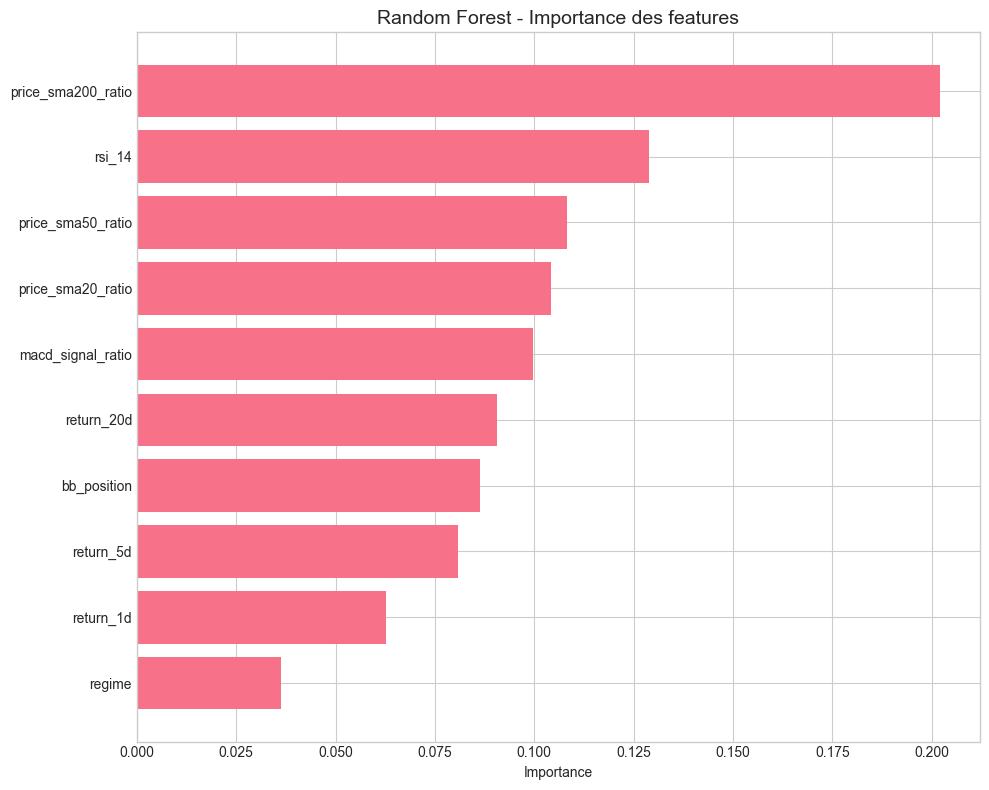

In [15]:
# Importance Random Forest (modèle choisi)
rf_importance = trained_models['Random Forest'].get_feature_importance()

fig, ax = plt.subplots(figsize=(10, 8))

rf_importance_sorted = rf_importance.sort_values('importance', ascending=True)
ax.barh(rf_importance_sorted['feature'], rf_importance_sorted['importance'])
ax.set_xlabel('Importance')
ax.set_title('Random Forest - Importance des features', fontsize=14)

plt.tight_layout()
plt.show()

## 10. Analyse des prédictions dans le temps

In [16]:
# Prédictions RF sur la période de test
rf_model = trained_models['Random Forest']
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred = rf_model.predict(X_test)

# Créer DataFrame pour analyse
analysis_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'proba': y_pred_proba,
    'correct': (y_test == y_pred).astype(int),
}, index=X_test.index)

# Rolling accuracy (fenêtre de 60 jours)
analysis_df['rolling_accuracy'] = analysis_df['correct'].rolling(60).mean()

print(f"Période test : {analysis_df.index.min().date()} à {analysis_df.index.max().date()}")
print(f"Accuracy globale : {analysis_df['correct'].mean()*100:.1f}%")

Période test : 2021-09-01 à 2026-05-05
Accuracy globale : 62.1%


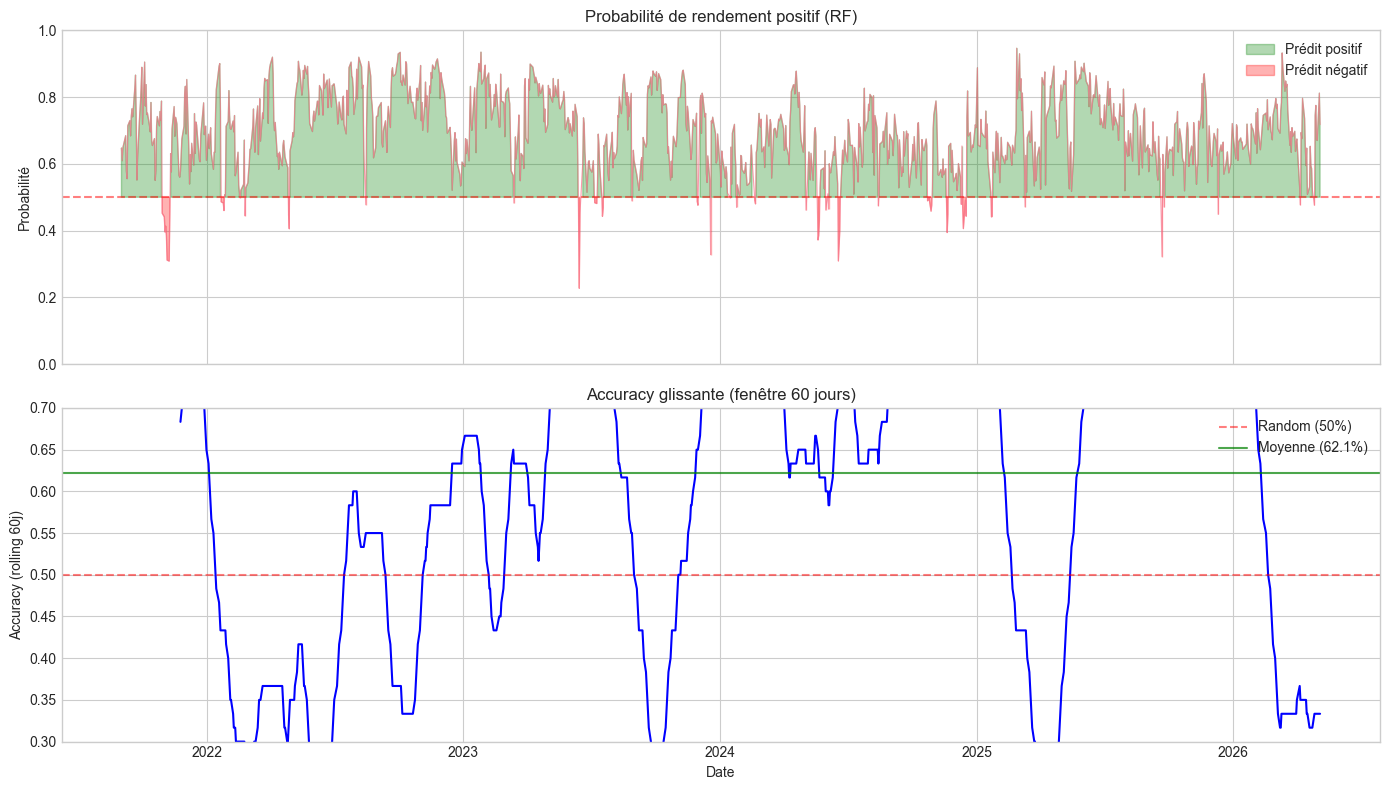

In [17]:
# Visualiser accuracy dans le temps
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Probabilité prédite
axes[0].plot(analysis_df.index, analysis_df['proba'], alpha=0.7, linewidth=0.8)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0].fill_between(analysis_df.index, 0.5, analysis_df['proba'], 
                     where=analysis_df['proba'] > 0.5, alpha=0.3, color='green', label='Prédit positif')
axes[0].fill_between(analysis_df.index, analysis_df['proba'], 0.5,
                     where=analysis_df['proba'] < 0.5, alpha=0.3, color='red', label='Prédit négatif')
axes[0].set_ylabel('Probabilité')
axes[0].set_title('Probabilité de rendement positif (RF)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 1)

# Rolling accuracy
axes[1].plot(analysis_df.index, analysis_df['rolling_accuracy'], color='blue', linewidth=1.5)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
axes[1].axhline(y=analysis_df['correct'].mean(), color='green', linestyle='-', alpha=0.7, 
                label=f"Moyenne ({analysis_df['correct'].mean()*100:.1f}%)")
axes[1].set_ylabel('Accuracy (rolling 60j)')
axes[1].set_xlabel('Date')
axes[1].set_title('Accuracy glissante (fenêtre 60 jours)', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].set_ylim(0.3, 0.7)

plt.tight_layout()
plt.show()

## 11. Conclusion

In [18]:
# Tableau récapitulatif final
print("\n" + "="*70)
print("RÉSUMÉ DE LA COMPARAISON DES MODÈLES DE PRÉDICTION")
print("="*70)

print("\n1. Split simple (70/30) :")
print(comparison_df.to_string())

print("\n2. Walk-Forward Validation :")
print(wf_results[['accuracy_mean', 'accuracy_std', 'auc_mean', 'overfit_gap_mean']].to_string())

print("\n" + "-"*70)
print("CONCLUSION")
print("-"*70)

# Déterminer le meilleur modèle
best_accuracy = comparison_df['accuracy'].idxmax()
best_auc = comparison_df['auc'].idxmax()
best_wf = wf_results['accuracy_mean'].idxmax()

print(f"\n1. Meilleure accuracy (split simple): {best_accuracy}")
print(f"2. Meilleur AUC (split simple): {best_auc}")
print(f"3. Meilleure accuracy (walk-forward): {best_wf}")

print("\n" + "-"*70)
print("""CHOIX FINAL: Random Forest

Justification:
- Performance stable en walk-forward (moins de variance)
- Bon équilibre accuracy/AUC
- Faible overfitting (gap train/test raisonnable)
- Feature importance interprétable
- Robuste aux outliers et au bruit

Features les plus importantes:
- Ratios SMA (tendance)
- RSI (momentum)
- Régime de marché
- Returns laggés

Limitations:
- Accuracy ~52-55% (marché efficient, difficile à battre)
- Performance varie selon les conditions de marché
- Ne prédit pas l'amplitude, seulement la direction
""")
print("-"*70)


RÉSUMÉ DE LA COMPARAISON DES MODÈLES DE PRÉDICTION

1. Split simple (70/30) :
                     accuracy     auc  precision  recall      f1  log_loss  overfit_gap
model                                                                                  
Logistic Regression    0.6300  0.4644     0.6300  1.0000  0.7730    0.6939       0.0792
XGBoost                0.5806  0.4942     0.6275  0.8227  0.7119    0.7958       0.2905
Random Forest          0.6215  0.4926     0.6328  0.9513  0.7600    0.7143       0.1732

2. Walk-Forward Validation :
                     accuracy_mean  accuracy_std  auc_mean  overfit_gap_mean
model                                                                       
Logistic Regression         0.5850        0.1093    0.5059            0.1232
XGBoost                     0.5608        0.0888    0.5057            0.4284
Random Forest               0.5565        0.1094    0.4840            0.3558

-----------------------------------------------------------------

In [19]:
# Sauvegarder les résultats
comparison_df.to_csv('../data/processed/prediction_model_comparison.csv')
wf_results.to_csv('../data/processed/prediction_walkforward_comparison.csv')
print("Résultats sauvegardés dans data/processed/")

Résultats sauvegardés dans data/processed/
